# Lesson 9: phenology extraction using COLD and S-CCD
**Author: Yingfan Zhang (zhangyingfanuk@163.com), Su Ye (remotesensingsuy@gmail.com)**

**Time series datasets: Harmonized Landsat-Sentinel (HLS) datasets**

**Application: land surface phenology**

Land surface phenology describes the timing of recurring seasonal changes in vegetation and other land-surface properties. Satellite time-series observations are particularly valuable for phenological analysis because they provide repeated measurements over multiple seasonal cycles. However, many existing phenology-extraction approaches do not explicitly account for spectral breaks caused by land-surface changes. Ignoring these breaks can introduce uncertainty into the estimated phenological metrics and limit the effective use of multi-year observations for robust temporal fitting.

In this lesson, we demonstrate a break-aware approach to phenology extraction using pyxccd. Specifically, we use temporal trajectories fitted by the Continuous monitoring of Land Disturbance (COLD) algorithm [1] and Stochastic Continuous Change Detection (S-CCD) [2] to characterize seasonal vegetation dynamics while accounting for structural breaks in the time series.

For each valid seasonal cycle, four phenological transition dates are identified relative to the seasonal peak:

- **greenup**: early rising phase of the seasonal cycle;
- **maturity**: late rising phase near the seasonal maximum;
- **senescence**: early falling phase after the seasonal maximum;
- **dormancy**: late falling phase approaching the seasonal minimum.

Rather than operating directly on individual satellite observations, the phenology functions are applied to the fitted temporal trajectories produced by COLD or S-CCD. This approach reduces the influence of irregular observation timing, missing observations, and short-term spectral noise. More importantly, structural breaks detected by COLD or S-CCD are used to delimit temporally consistent segments, helping ensure that phenological metrics are extracted only from valid seasonal cycles within periods of relatively stable land-surface conditions.

The detailed methodology underlying this break-aware phenology framework will be presented in the incoming publication [3].

References:

*[1] Zhu, Z., Zhang, J., Yang, Z., Aljaddani, A. H., Cohen, W. B., Qiu, S., & Zhou, C. (2020). Continuous monitoring of land disturbance based on Landsat time series. Remote Sensing of Environment, 238, 111116.*

*[2] Ye, S., Rogan, J., Zhu, Z., & Eastman, J. R. (2021). A near-real-time approach for monitoring forest disturbance using Landsat time series: Stochastic continuous change detection. Remote Sensing of Environment, 252, 112167.*

*[3] Zhang, Y., ..., Ye, S. (2026). Moderate-resolution satellite time series reveal coupled management–climate controls on global cropland phenological shifts. Under review.*


## Preparing the HLS time series

The example dataset is stored in `tutorials/datasets/9_phenology_hls.csv`. It contains one HLS pixel time series with Green, Red, NIR, SWIR1, SWIR2, EVI, and QA values.

EVI has already been calculated and stored as an integer scaled by 10,000. 





In [1]:
import pathlib

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from pyxccd import (
    cold_detect_flex,
    cold_extract_phenology,
    sccd_detect_flex,
    sccd_extract_phenology,
)
from pyxccd.utils import coefficient_matrix


TUTORIAL_DATASET = (pathlib.Path.cwd() / "datasets").resolve()

if not TUTORIAL_DATASET.exists():
    TUTORIAL_DATASET = (pathlib.Path.cwd().parent / "datasets").resolve()

data = pd.read_csv(
    TUTORIAL_DATASET / "9_phenology_hls.csv"
).sort_values(
    "dates",
    kind="mergesort",
).reset_index(drop=True)

dates = data["dates"].to_numpy(dtype=np.int64)
qas = data["qa"].to_numpy(dtype=np.int64)
evi = data["evi"].to_numpy(dtype=np.float64)

stack = data[
    ["green", "red", "nir", "swir1", "swir2", "evi"]
].to_numpy(dtype=np.float64)

PHENOLOGY_BAND = 6


## Extracting COLD phenology


`cold_extract_phenology` reconstructs the fitted curve for the selected band and searches for seasonal peaks within the COLD segments. Greenup, maturity, senescence, and dormancy are then calculated relative to the amplitude of each retained fitted EVI cycle.

The default settings use:

- a relative peak ratio of 0.35;
- 15% and 90% amplitude thresholds for the four phenological transition dates.



In [2]:
cold_result = cold_detect_flex(
    dates,
    stack,
    qas,
    lam=20,
    p_cg=0.99,
    conse=6,
    tmask_b1_index=1,
    tmask_b2_index=4,
)

cold_phenology = cold_extract_phenology(
    cold_result,
    PHENOLOGY_BAND,
    peak_threshold=400
)

cold_phenology


,position,t_start,t_end,break_date,fitted_peak_date,fitted_peak,greenup,maturity,senescence,dormancy
0,1,735915,738643,738660,736192,7271.669922,736131,736176,736209,736256
1,1,735915,738643,738660,736557,7317.693359,736496,736541,736574,736622
2,1,735915,738643,738660,736922,7363.424316,736861,736906,736939,736987
3,1,735915,738643,738660,737287,7408.855469,737227,737272,737304,737352
4,1,735915,738643,738660,737653,7454.193359,737592,737637,737670,737717
5,1,735915,738643,738660,738018,7500.232422,737957,738002,738035,738083
6,1,735915,738643,738660,738383,7545.963379,738322,738367,738400,738448
7,1,738755,739615,0,739073,5631.390137,739005,739057,739091,739146
8,1,738755,739615,0,739439,5888.206543,739371,739422,0,0


### Interpreting the COLD phenology table

The output includes the COLD segment containing that peak and the associated phenological transition dates.

| Column | Meaning |
| :--- | :--- |
| `position` | Pixel or time-series position identifier |
| `t_start` | Start of the fitted segment |
| `t_end` | End of the fitted segment |
| `break_date` | Structural break associated with the segment |
| `fitted_peak_date` | Date of the fitted EVI maximum |
| `fitted_peak` | Fitted EVI value at the maximum |
| `greenup` | Early rising-phase transition |
| `maturity` | Late rising-phase transition |
| `senescence` | Early falling-phase transition |
| `dormancy` | Late falling-phase transition |

All dates are Python ordinal dates, consistent with the date convention used by pyxccd. A value of `0` indicates that the corresponding transition could not be determined reliably. This commonly occurs when a seasonal cycle is truncated by a segment boundary or structural break.


### Displaying the COLD result

The figure below combines four types of information:

- green points: clear HLS EVI observations;
- orange lines: fitted COLD EVI curves;
- red vertical lines: detected structural breaks;
- black points: greenup, maturity, senescence, and dormancy dates.



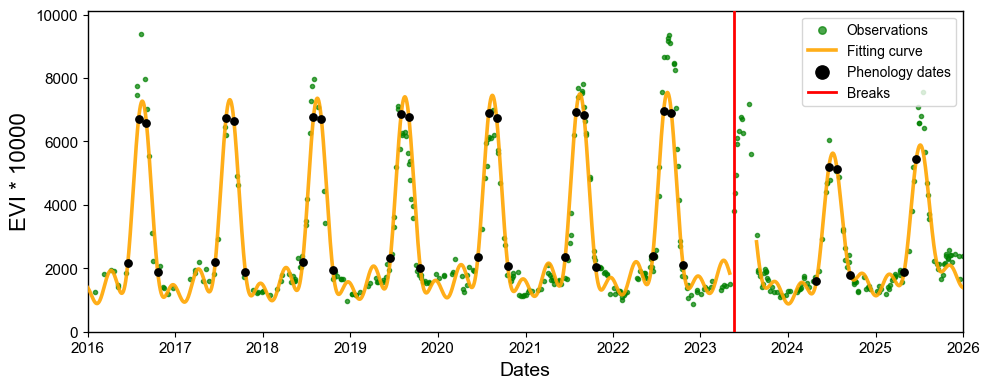

In [3]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

def _to_date(value):
    return pd.Timestamp.fromordinal(int(value))


def _format_evi_axis(ax, start_date, end_date, upper):
    ax.set_facecolor("white")
    ax.figure.set_facecolor("white")
    ax.grid(False)

    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(1.0)

    ax.set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))
    ax.set_ylim(0, upper)
    ax.set_ylabel("EVI * 10000", fontsize=16)
    ax.set_xlabel("Dates", fontsize=14)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="both", labelsize=11, direction="out")


def _cold_fitted_curve(cold_result, band):
    curves = []

    for segment_id, segment in enumerate(cold_result):
        t_start = int(segment["t_start"])
        t_end = int(segment["t_end"])

        if t_start <= 0 or t_end < t_start:
            continue

        ordinal = np.arange(t_start, t_end + 1, dtype=np.int64)
        coefs = np.asarray(
            segment["coefs"][band - 1],
            dtype=np.float64,
        ).ravel()

        ncoef = min(len(coefs), 8)

        design = np.vstack(
            [
                np.asarray(
                    coefficient_matrix(int(day), ncoef),
                    dtype=np.float64,
                )[:ncoef]
                for day in ordinal
            ]
        )

        curves.append(
            pd.DataFrame(
                {
                    "ordinal": ordinal,
                    "date": [_to_date(day) for day in ordinal],
                    "value": design @ coefs[:ncoef],
                    "segment_id": segment_id,
                    "t_start": t_start,
                    "t_end": t_end,
                }
            )
        )

    return pd.concat(curves, ignore_index=True)


def display_cold_evi(
    data,
    cold_result,
    phenology_result,
    band=6,
    start_date="2016-01-01",
    end_date="2026-01-01",
):
    clear = data[
        (data["qa"] == 0) | (data["qa"] == 1)
    ].copy()

    clear["date"] = clear["dates"].map(_to_date)
    fitted = _cold_fitted_curve(cold_result, band)

    fig, ax = plt.subplots(figsize=(10, 4))

    obs = ax.scatter(
        clear["date"],
        clear["evi"],
        color="green",
        s=9,
        alpha=0.7,
        label="Observations",
        zorder=2,
    )

    fit = None

    for _, curve in fitted.groupby("segment_id", sort=False):
        line, = ax.plot(
            curve["date"],
            curve["value"],
            color="orange",
            linewidth=2.6,
            alpha=0.9,
            label="Fitting curve" if fit is None else "_nolegend_",
            zorder=3,
        )

        if fit is None:
            fit = line

    event_x = []
    event_y = []

    for _, row in phenology_result.iterrows():
        segment_curve = fitted[
            (fitted["t_start"] == int(row["t_start"]))
            & (fitted["t_end"] == int(row["t_end"]))
        ]

        for column in [
            "greenup",
            "maturity",
            "senescence",
            "dormancy",
        ]:
            event_date = int(row[column])

            if event_date <= 0:
                continue

            point = segment_curve[
                segment_curve["ordinal"] == event_date
            ]

            if not point.empty:
                event_x.append(_to_date(event_date))
                event_y.append(float(point.iloc[-1]["value"]))

    events = ax.scatter(
        event_x,
        event_y,
        color="black",
        s=28,
        label="Phenology dates",
        zorder=5,
    )

    for break_date in sorted(
        {
            int(segment["t_break"])
            for segment in cold_result
            if int(segment["t_break"]) > 0
        }
    ):
        break_timestamp = _to_date(break_date)

        if pd.Timestamp(start_date) <= break_timestamp <= pd.Timestamp(end_date):
            ax.axvline(
                break_timestamp,
                color="red",
                linewidth=2.0,
                zorder=4,
            )

    breaks = Line2D(
        [0],
        [0],
        color="red",
        linewidth=2.0,
        label="Breaks",
    )

    data_upper = max(
        np.nanquantile(clear["evi"], 0.98),
        np.nanmax(fitted["value"]),
        1000,
    )

    upper = data_upper * 1.2

    _format_evi_axis(
        ax,
        start_date,
        end_date,
        upper,
    )

    ax.legend(
        handles=[obs, fit, events, breaks],
        loc="upper right",
        fontsize=10,
        markerscale=1.8,
        frameon=True,
        facecolor="white",
        edgecolor="0.8",
    )

    fig.tight_layout()

    return fig, ax


display_cold_evi(
    data,
    cold_result,
    cold_phenology,
);


## Extracting S-CCD phenology

S-CCD differs from COLD because it updates its temporal model recursively. When `state_intervaldays` is greater than zero, `sccd_detect_flex` returns fitted state components at a regular interval.

For phenology extraction, the trend, annual, semiannual, and trimodal state components of the selected EVI band are summed to reconstruct the fitted trajectory. In this lesson, daily fitted states are requested with `state_intervaldays=1`, allowing phenological transitions to be identified at daily resolution.

The sixth value in `lam` corresponds to EVI. A smaller value is used for EVI in this example because its noise and scaling behavior differ from the five reflectance bands.


In [4]:
sccd_result, state_result = sccd_detect_flex(
    dates,
    stack,
    qas,
    lam=[20, 20, 20, 20, 20, 0.1],
    p_cg=0.99,
    conse=6,
    state_intervaldays=1,
    b_c2=True,
    fitting_coefs=True,
    trimodal=True,
    tmask_b1_index=1,
    tmask_b2_index=4,
)

sccd_phenology = sccd_extract_phenology(
    state_result,
    sccd_result,
    PHENOLOGY_BAND,
    peak_threshold=400
)

sccd_phenology


,position,t_start,t_end,break_date,fitted_peak_date,fitted_peak,greenup,maturity,senescence,dormancy
0,1,735755,738660,738660,735819,8618.175781,0,0,735837,735880
1,1,735755,738660,738660,736187,8648.674805,736126,736172,736204,736245
2,1,735755,738660,738660,736552,7840.273438,736487,736528,736568,736614
3,1,735755,738660,738660,736918,7963.008789,736856,736903,736932,736973
4,1,735755,738660,738660,737274,7227.896973,737217,737263,737294,737339
5,1,735755,738660,738660,737644,6390.081055,737579,737629,737665,737711
6,1,735755,738660,738660,738030,6834.507812,737952,738010,738040,738083
7,1,735755,738660,738660,738390,8305.323242,738326,738380,738404,738449
8,1,738755,739560,0,739072,5430.487305,738999,739059,739089,739145
9,1,738755,739560,0,739450,6494.134766,739366,739435,739460,739496


### Interpreting the S-CCD phenology table

The S-CCD and COLD phenology functions return the same output columns, allowing both results to be processed using a consistent downstream workflow.

As with COLD, zero-valued phenological dates indicate that one side of the seasonal cycle was incomplete or interrupted.


### Displaying the S-CCD result

The S-CCD figure uses the same graphical structure as the COLD figure:

- green points show clear EVI observations;
- the orange curve shows the reconstructed fitted EVI state;
- red vertical lines show confirmed S-CCD breaks;
- black points show the extracted phenological dates.



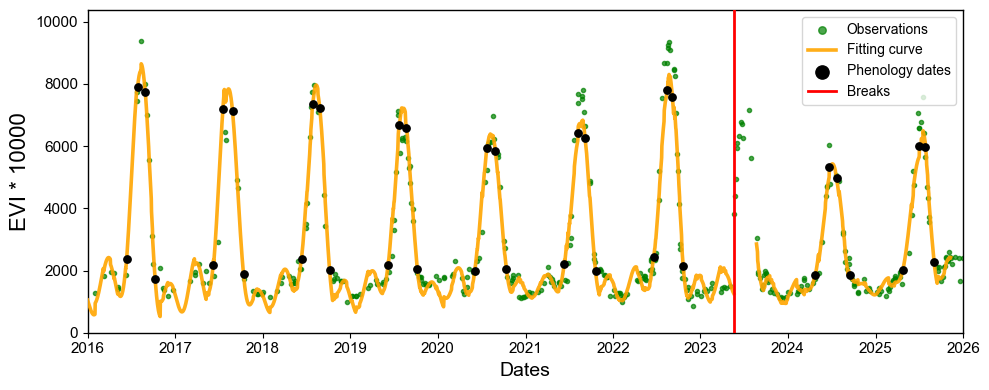

In [5]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

def _iter_sccd_segments(rec_cg):
    if rec_cg is None:
        return

    if hasattr(rec_cg, "t_start") and hasattr(rec_cg, "t_break"):
        for t_start, t_break in zip(
            np.atleast_1d(rec_cg.t_start),
            np.atleast_1d(rec_cg.t_break),
        ):
            yield int(t_start), int(t_break)
        return

    for segment in rec_cg:
        if isinstance(segment, dict):
            yield int(segment["t_start"]), int(segment["t_break"])
        else:
            yield int(segment["t_start"]), int(segment["t_break"])


def _sccd_fitted_curve(state_result, band):
    fitted = state_result.copy().sort_values(
        "dates",
        kind="mergesort",
    ).reset_index(drop=True)

    fitted["ordinal"] = fitted["dates"].to_numpy(dtype=np.int64)
    fitted["date"] = fitted["ordinal"].map(_to_date)

    band0 = band - 1
    fitted["value"] = 0.0

    for column in [
        f"b{band0}_trend",
        f"b{band0}_annual",
        f"b{band0}_semiannual",
        f"b{band0}_trimodal",
    ]:
        if column in fitted.columns:
            fitted["value"] += fitted[column].to_numpy(dtype=np.float64)

    return fitted


def display_sccd_evi(
    data,
    sccd_result,
    state_result,
    phenology_result,
    band=6,
    start_date="2016-01-01",
    end_date="2026-01-01",
):
    clear = data[
        (data["qa"] == 0) | (data["qa"] == 1)
    ].copy()

    clear["date"] = clear["dates"].map(_to_date)
    fitted = _sccd_fitted_curve(state_result, band)


    # ============================================================
    # Only retain state values covered by SCCD models
    # ============================================================
    state_ord = fitted["ordinal"].to_numpy(dtype=np.int64)
    covered = np.zeros(len(fitted), dtype=bool)

    # 1. Confirmed SCCD segments: t_start ~ t_break
    rec_cg = getattr(sccd_result, "rec_cg", None)

    for t_start, t_break in _iter_sccd_segments(rec_cg):
        if t_start <= 0 or t_break <= 0:
            continue

        covered |= (
            (state_ord >= t_start)
            & (state_ord <= t_break)
        )


    # 2. Current NRT model: nrt_start ~ end_date
    nrt_model = getattr(sccd_result, "nrt_model", None)

    if nrt_model is not None:

        if isinstance(nrt_model, dict):
            t0 = nrt_model.get("t_start_since1982")

        elif (
            hasattr(nrt_model, "dtype")
            and nrt_model.dtype.names
            and "t_start_since1982" in nrt_model.dtype.names
        ):
            t0 = nrt_model["t_start_since1982"]

        else:
            t0 = getattr(
                nrt_model,
                "t_start_since1982",
                None,
            )

        if t0 is not None:
            t0 = int(np.atleast_1d(t0).flat[0])

            # SCCD date relative to 1982-01-01
            nrt_start_ord = t0 + 723742
            end_ord = pd.Timestamp(end_date).toordinal()

            covered |= (
                (state_ord >= nrt_start_ord)
                & (state_ord <= end_ord)
            )


    # Remove unstable/uncovered state values
    fitted = (
        fitted.loc[covered]
        .copy()
        .reset_index(drop=True)
    )


    fig, ax = plt.subplots(figsize=(10, 4))


    obs = ax.scatter(
        clear["date"],
        clear["evi"],
        color="green",
        s=9,
        alpha=0.7,
        label="Observations",
        zorder=2,
    )

    gap_group = (
        fitted["date"].diff().dt.days.fillna(0) > 40
    ).cumsum()

    fit = None

    for _, curve in fitted.groupby(gap_group, sort=False):
        if len(curve) < 2:
            continue

        line, = ax.plot(
            curve["date"],
            curve["value"],
            color="orange",
            linewidth=2.6,
            alpha=0.9,
            label="Fitting curve" if fit is None else "_nolegend_",
            zorder=3,
        )

        if fit is None:
            fit = line

    fitted_dates = fitted["ordinal"].to_numpy(dtype=np.int64)
    fitted_values = fitted["value"].to_numpy(dtype=np.float64)

    event_x = []
    event_y = []

    for _, row in phenology_result.iterrows():
        for column in [
            "greenup",
            "maturity",
            "senescence",
            "dormancy",
        ]:
            event_date = int(row[column])

            if event_date <= 0:
                continue

            nearest = int(
                np.abs(fitted_dates - event_date).argmin()
            )

            event_x.append(_to_date(event_date))
            event_y.append(fitted_values[nearest])

    events = ax.scatter(
        event_x,
        event_y,
        color="black",
        s=28,
        label="Phenology dates",
        zorder=5,
    )

    for _, break_date in _iter_sccd_segments(
        getattr(sccd_result, "rec_cg", None)
    ):
        if break_date <= 0:
            continue

        break_timestamp = _to_date(break_date)

        if pd.Timestamp(start_date) <= break_timestamp <= pd.Timestamp(end_date):
            ax.axvline(
                break_timestamp,
                color="red",
                linewidth=2.0,
                zorder=4,
            )

    breaks = Line2D(
        [0],
        [0],
        color="red",
        linewidth=2.0,
        label="Breaks",
    )

    data_upper = max(
        np.nanquantile(clear["evi"], 0.98),
        np.nanmax(fitted["value"]),
        1000,
    )

    upper = data_upper * 1.2

    _format_evi_axis(
        ax,
        start_date,
        end_date,
        upper,
    )

    ax.legend(
        handles=[obs, fit, events, breaks],
        loc="upper right",
        fontsize=10,
        markerscale=1.8,
        frameon=True,
        facecolor="white",
        edgecolor="0.8",
    )

    fig.tight_layout()

    return fig, ax


display_sccd_evi(
    data,
    sccd_result,
    state_result,
    sccd_phenology,
);


## Comparing COLD and S-CCD phenology

COLD uses a harmonic regression model with a fixed set of coefficients within each temporal segment. The seasonal components therefore repeat with approximately the same shape and phase from year to year until a new structural break is detected. A substantial change in phenological timing is usually represented by the beginning of a new COLD segment with a different set of harmonic coefficients.

S-CCD uses a state-space model in which the trend and seasonal states are updated sequentially as new observations become available. Consequently, the fitted seasonal trajectory is allowed to evolve gradually over time, even when no structural break is detected. The timing of greenup, maturity, peak, senescence, and dormancy can therefore vary from year to year within the same S-CCD segment. This behavior allows S-CCD to represent gradual phenological shifts, such as progressively earlier greenup or delayed senescence, without requiring an abrupt change point.

In summary, COLD describes phenology as a relatively stable and repeating seasonal pattern within each fitted segment, whereas S-CCD allows phenological timing and seasonal shape to change continuously through state updates. 


## Summary

This lesson demonstrated a compact workflow for extracting EVI phenology with pyxccd:

1. Read a precomputed HLS EVI time series.
2. Place EVI in the sixth position of a flexible multiband stack.
3. Run `cold_detect_flex` and extract phenology with `cold_extract_phenology`.
4. Run `sccd_detect_flex` with daily fitted states and extract phenology with `sccd_extract_phenology`.
5. Display observations, fitted EVI trajectories, structural breaks, and phenological dates.


